In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/habibamuhammed1/arabic-toxic/arabic_tweets_dataset_combined.csv
/kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4
/kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4


In [108]:
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import EarlyStopping

Dataset Shape: (45275, 2)

Missing Values:
 label    0
text     0
dtype: int64

Duplicates: 15721

Class Distribution:
 label
pos    22761
neg    22514
Name: count, dtype: int64


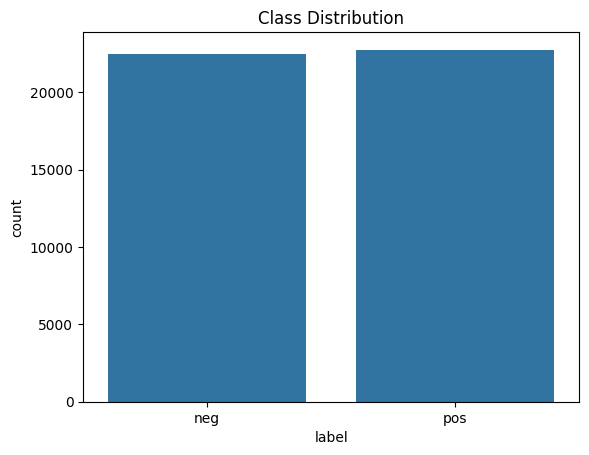

In [109]:
df = pd.read_csv("/kaggle/input/datasets/habibamuhammed1/arabic-toxic/arabic_tweets_dataset_combined.csv")

print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nClass Distribution:\n", df["label"].value_counts())

sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.show()

In [110]:
print("=" * 70)

print("POSITIVE SAMPLES")

print("=" * 70)

positive_samples = df[df["label"] == "pos"]["text"].head(5)

for i, text in enumerate(positive_samples):

    print(f"\n[{i+1}]")

    print(text)

    print("-" * 70)


print("\n\n")


print("=" * 70)

print("NEGATIVE SAMPLES")

print("=" * 70)

negative_samples = df[df["label"] == "neg"]["text"].head(5)

for i, text in enumerate(negative_samples):

    print(f"\n[{i+1}]")

    print(text)

    print("-" * 70)

POSITIVE SAMPLES

[1]
لا ده صاحب مزاج هيخلص على العسل كلوو 😂
----------------------------------------------------------------------

[2]
صباح الخير والاجواء الزينه.. 🌸
----------------------------------------------------------------------

[3]
خارج النص | - فرحة مشجع عماني في نهائي كأس جلالة السلطان قابوس 😂
----------------------------------------------------------------------

[4]
لاترمون فساد وخراب بلدانكم على ال سعود انتم من عبثتم في وطنكم 😄
----------------------------------------------------------------------

[5]
✍🏻 ﻋﻨﺪﻣﺎ ﻳﺤﺒﺲ ﺍﻟﻀﻴﻖ ﺃﻧﻔﺎﺳﻚ ﺇﺭﺗﺸﻒ ﻣﺎﺀ ﺍﻹﻃﻤﺌﻨﺎﻥ ﻭﺃﻧﺖ ﺗﺮﺩﺩ : *ﺭﺑﻲ ﺇﺷﺮﺡ ﻟﻲ ﺻﺪﺭﻱ ، ﻭﻳﺴﺮ ﻟﻲ ﺃﻣﺮﻱ* .. * 🌹…
----------------------------------------------------------------------



NEGATIVE SAMPLES

[1]
اقول ياحظكم بالبرد وربي ودي عندكم 😭
----------------------------------------------------------------------

[2]
تخاف آ يطرا لينا بحال المونديال و نخسرو مع ناميبيا اللي كلشي حاكرها 😶
----------------------------------------------------------------------

[3]
ممكن كل شيء جايز 🤔 ال

In [111]:
def clean_text(text):
    text = str(text)

    # Remove URLs and mentions
    text = re.sub(r'https?://\S+|www\.\S+|@\w+', '', text)

    # Remove Arabic diacritics
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0640]', '', text)

    # Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)

    # Keep Arabic text and spaces
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)

    # Remove extra spaces
    return re.sub(r'\s+', ' ', text).strip()


# Clean dataset
df = df.dropna(subset=["text", "label"]).copy()

df["clean_text"] = df["text"].apply(clean_text)

# Convert labels to numbers
label_map = {
    "neg": 0,
    "pos": 1
}

df["label_encoded"] = (
    df["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(label_map)
)

# Remove invalid rows
df = df.dropna(subset=["clean_text", "label_encoded"])
df = df[df["clean_text"] != ""]

# IMPORTANT: numeric labels
df["label_encoded"] = df["label_encoded"].astype(np.float32)

print("Final Shape:", df.shape)
print(df["label_encoded"].value_counts())

Final Shape: (45258, 4)
label_encoded
1.0    22756
0.0    22502
Name: count, dtype: int64


In [112]:
X = df["clean_text"].astype(str).to_numpy()
y = df["label_encoded"].astype(np.float32).to_numpy()

# 70% Train / 15% Validation / 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Labels dtype:", y_train.dtype)
print("Labels:", np.unique(y_train))

Train: (31680,)
Validation: (6789,)
Test: (6789,)
Labels dtype: float32
Labels: [0. 1.]


In [113]:
MAX_WORDS = 15000
MAX_LEN = 50

vectorizer = TextVectorization(
    max_tokens=MAX_WORDS,
    output_mode="int",
    output_sequence_length=MAX_LEN
)

vectorizer.adapt(
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .batch(256)
)

VOCAB_SIZE = len(vectorizer.get_vocabulary())

print("Vocabulary Size:", VOCAB_SIZE)

Vocabulary Size: 15000


In [114]:
model = tf.keras.Sequential([
    
    tf.keras.Input(shape=(1,), dtype=tf.string),

    vectorizer,

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64,
        mask_zero=True
    ),

    SpatialDropout1D(0.2),

    Bidirectional(LSTM(32)),

    Dropout(0.3),

    Dense(16, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ (None, 50)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 64)         │       960,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 50, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 985,889 (3.76 MB)

 Trainable params: 985,889 (3.76 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [116]:
BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices(
    (
        tf.constant(X_train, dtype=tf.string),
        tf.constant(y_train, dtype=tf.float32)
    )
).shuffle(10000).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (
        tf.constant(X_val, dtype=tf.string),
        tf.constant(y_val, dtype=tf.float32)
    )
).batch(BATCH_SIZE)


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7205 - auc: 0.8075 - loss: 0.5171 - val_accuracy: 0.7677 - val_auc: 0.8594 - val_loss: 0.4494
Epoch 2/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8205 - auc: 0.9095 - loss: 0.3700 - val_accuracy: 0.7671 - val_auc: 0.8636 - val_loss: 0.4527
Epoch 3/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8649 - auc: 0.9472 - loss: 0.2862 - val_accuracy: 0.7657 - val_auc: 0.8614 - val_loss: 0.5251
Epoch 4/15
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8994 - auc: 0.9703 - loss: 0.2172 - val_accuracy: 0.7658 - val_auc: 0.8568 - val_loss: 0.6318


In [117]:
# Predict probabilities
y_probs = model.predict(
    tf.constant(X_test, dtype=tf.string),
    batch_size=64,
    verbose=0
).flatten()


# Find best threshold using F1 Score
thresholds = np.arange(0.30, 0.71, 0.01)

f1_scores = [
    f1_score(
        y_test,
        (y_probs >= t).astype(int),
        zero_division=0
    )
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f1_scores)]


# Final predictions
y_pred = (y_probs >= best_threshold).astype(int)


# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_probs)


print("=" * 55)
print("FINAL MODEL RESULTS")
print("=" * 55)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"AUC Score      : {auc:.4f}")

FINAL MODEL RESULTS
Best Threshold : 0.39
Accuracy       : 0.7385
Precision      : 0.6999
Recall         : 0.8403
F1 Score       : 0.7637
AUC Score      : 0.8537


In [119]:
print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)


# Accuracy for each class
for class_id, class_name in enumerate(["Negative", "Positive"]):

    mask = y_test == class_id

    class_accuracy = np.mean(
        y_pred[mask] == y_test[mask]
    )

    print(
        f"{class_name} Accuracy: "
        f"{class_accuracy:.4f}"
    )


CLASSIFICATION REPORT

              precision    recall  f1-score   support

    Negative       0.80      0.64      0.71      3376
    Positive       0.70      0.84      0.76      3413

    accuracy                           0.74      6789
   macro avg       0.75      0.74      0.74      6789
weighted avg       0.75      0.74      0.74      6789

Negative Accuracy: 0.6357
Positive Accuracy: 0.8403


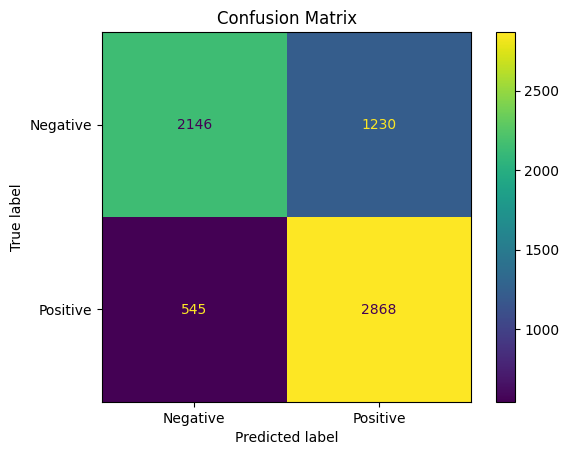

In [120]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

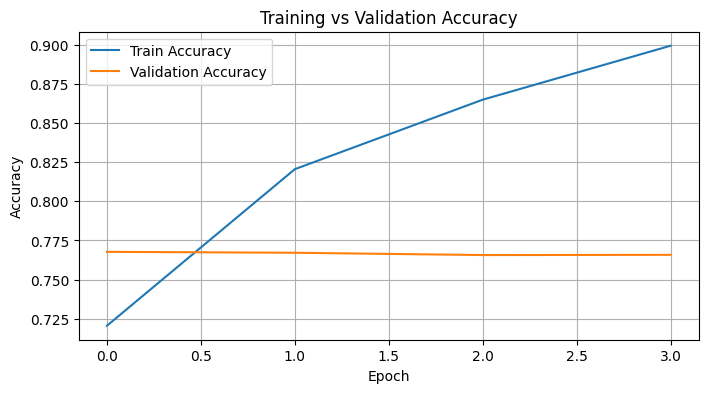

In [121]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

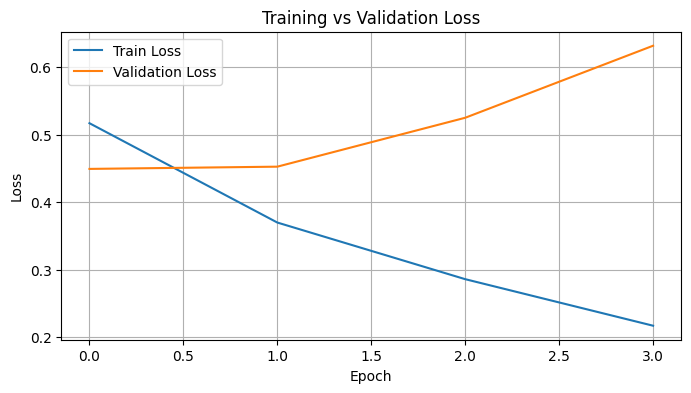

In [122]:
plt.figure(figsize=(8, 4))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()
plt.show()

In [123]:
def predict_text(text):

    cleaned = clean_text(text)

    probability = float(
        model.predict(
            tf.constant([cleaned], dtype=tf.string),
            verbose=0
        )[0][0]
    )

    prediction = (
        "Positive"
        if probability >= best_threshold
        else "Negative"
    )

    positive_prob = probability * 100
    negative_prob = (1 - probability) * 100

    print("=" * 50)
    print("Input Text:", text)
    print("-" * 50)
    print(f"Positive Probability: {positive_prob:.2f}%")
    print(f"Negative Probability: {negative_prob:.2f}%")
    print(f"Prediction: {prediction}")
    print(f"Threshold: {best_threshold:.2f}")
    print("=" * 50)

    return prediction

In [124]:
predict_text("أنا سعيد جدا وأحب الحياة")

predict_text("أنا حزين جدا وأشعر بالغضب")

Input Text: أنا سعيد جدا وأحب الحياة
--------------------------------------------------
Positive Probability: 77.51%
Negative Probability: 22.49%
Prediction: Positive
Threshold: 0.39
Input Text: أنا حزين جدا وأشعر بالغضب
--------------------------------------------------
Positive Probability: 23.47%
Negative Probability: 76.53%
Prediction: Negative
Threshold: 0.39


'Negative'

In [125]:
MODEL_PATH = "/kaggle/working/arabic_sentiment.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")

Model saved successfully!


In [126]:
!pip install -q openai-whisper

In [127]:
import whisper

speech_model = whisper.load_model("small")

In [128]:
def predict_text(text):

    input_tensor = tf.constant([str(text)], dtype=tf.string)

    positive_probability = float(
        new_model.predict(input_tensor, verbose=0)[0][0]
    )

    negative_probability = 1 - positive_probability

    # Choose class with higher probability
    if positive_probability >= negative_probability:
        prediction = "Positive"
    else:
        prediction = "Negative"

    print("=" * 50)
    print("Input Text:")
    print(text)
    print("-" * 50)
    print(f"Positive Probability: {positive_probability * 100:.2f}%")
    print(f"Negative Probability: {negative_probability * 100:.2f}%")
    print(f"Prediction: {prediction}")
    print("=" * 50)

    return prediction

In [129]:
# Predict probabilities on test data
y_pred_probs = model.predict(
    tf.constant(X_test, dtype=tf.string),
    batch_size=64,
    verbose=0
).flatten()

# Make sure test labels are numeric
y_test_new = y_test.astype(int)

print("Prediction shape:", y_pred_probs.shape)
print("Test labels shape:", y_test_new.shape)

Prediction shape: (6789,)
Test labels shape: (6789,)


In [130]:
thresholds = np.arange(0.30, 0.71, 0.01)

f1_scores = []

for t in thresholds:
    temp_pred = (y_pred_probs >= t).astype(int)
    score = f1_score(y_test_new, temp_pred, zero_division=0)
    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best Threshold:", best_threshold)
print("Best F1:", max(f1_scores))

Best Threshold: 0.39000000000000007
Best F1: 0.7636799360937292


In [131]:
print(df[["label", "label_encoded"]].drop_duplicates())

  label  label_encoded
0   neg            0.0
2   pos            1.0


In [132]:
!pip install -q openai-whisper

In [138]:
import whisper

In [140]:
speech_model = whisper.load_model("base")

In [174]:
def predict_text(text):

    cleaned_text = clean_text(text)

    input_tensor = tf.constant(
        [cleaned_text],
        dtype=tf.string
    )

    positive_probability = float(
        model.predict(input_tensor, verbose=0)[0][0]
    )

    negative_probability = 1 - positive_probability

    # Use 0.5 for final sentiment decision
    prediction = (
        "Positive"
        if positive_probability >= 0.5
        else "Negative"
    )

    print("=" * 50)
    print("Input Text:")
    print(text)
    print("-" * 50)
    print(f"Positive Probability: {positive_probability * 100:.2f}%")
    print(f"Negative Probability: {negative_probability * 100:.2f}%")
    print(f"Prediction: {prediction}")
    print("=" * 50)

    return prediction

In [175]:
predict_audio(
    "/kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4"
)

Function is working!
Audio path: /kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4


In [168]:
predict_audio(
    "/kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4"
)

Function is working!
Audio path: /kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4


In [176]:
test_samples = [
    "أنا سعيد جدا وأحب الحياة",
    "هذا يوم جميل وأنا أشعر بالسعادة",
    "أنا حزين جدا وأشعر بالغضب",
    "هذا شيء سيء جدا وأنا أكرهه"
]

for text in test_samples:
    print("\nTEXT:", text)
    predict_text(text)


TEXT: أنا سعيد جدا وأحب الحياة
Input Text:
أنا سعيد جدا وأحب الحياة
--------------------------------------------------
Positive Probability: 77.51%
Negative Probability: 22.49%
Prediction: Positive

TEXT: هذا يوم جميل وأنا أشعر بالسعادة
Input Text:
هذا يوم جميل وأنا أشعر بالسعادة
--------------------------------------------------
Positive Probability: 47.80%
Negative Probability: 52.20%
Prediction: Negative

TEXT: أنا حزين جدا وأشعر بالغضب
Input Text:
أنا حزين جدا وأشعر بالغضب
--------------------------------------------------
Positive Probability: 23.47%
Negative Probability: 76.53%
Prediction: Negative

TEXT: هذا شيء سيء جدا وأنا أكرهه
Input Text:
هذا شيء سيء جدا وأنا أكرهه
--------------------------------------------------
Positive Probability: 27.31%
Negative Probability: 72.69%
Prediction: Negative


In [177]:
def analyze_video(video_path, video_name):

    # Speech to Text
    result = speech_model.transcribe(
        video_path,
        language="ar"
    )

    extracted_text = result["text"].strip()

    # Model Prediction
    input_tensor = tf.constant(
        [extracted_text],
        dtype=tf.string
    )

    positive_probability = float(
            model.predict(
            input_tensor,
            verbose=0
        )[0][0]
    )

    negative_probability = 1 - positive_probability

    # Final class based on highest probability
    if positive_probability >= 0.5:
        prediction = "Positive"
    else:
        prediction = "Negative"

    confidence = max(
        positive_probability,
        negative_probability
    ) * 100

    return {
        "Video": video_name,
        "Extracted Text": extracted_text,
        "Positive Probability": positive_probability * 100,
        "Negative Probability": negative_probability * 100,
        "Prediction": prediction,
        "Confidence": confidence
    }

In [178]:
video1 = analyze_video(
    "/kaggle/input/datasets/habibamuhammed1/negative/WhatsApp Video 2026-09-03 at 1.47.38 AM.mp4",
    "Negative Video"
)

In [179]:
video2 = analyze_video(
    "/kaggle/input/datasets/habibamuhammed1/pos-video/WhatsApp Video 2026-09-03 at 7.55.55 AM.mp4",
    "Positive Video"
)

In [181]:
comparison = pd.DataFrame([video1, video2])

comparison

,Video,Extracted Text,Positive Probability,Negative Probability,Prediction,Confidence
0,Negative Video,أولئ المجرمون البيلقال بالبيلارحمة الذين لا يف...,48.359549,51.640451,Negative,51.640451
1,Positive Video,أهلا يقولون وجود الناس اللطيفة في حيات كنامه و...,57.322216,42.677784,Positive,57.322216


In [184]:
# Save the trained model
MODEL_PATH = "/kaggle/working/arabic_sentiment.keras"

model.save(MODEL_PATH)

print("✅ Model saved successfully!")
print("📁 Path:", MODEL_PATH)

✅ Model saved successfully!
📁 Path: /kaggle/working/arabic_sentiment.keras
